<a href="https://colab.research.google.com/github/dyyland23-glitch/Marketing-sales-data/blob/main/marketing_Run%20simple%20linear%20regression%20(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity: Run simple linear regression

## **Introduction**


As you're learning, simple linear regression is a way to model the relationship between two variables. By assessing the direction and magnitude of a relationship, data professionals are able to uncover patterns and transform large amounts of data into valuable knowledge. This enables them to make better predictions and decisions.

In this lab, you are part of an analytics team that provides insights about your company's sales and marketing practices. You have been assigned to a project that focuses on the use of influencer marketing. For this task, you will explore the relationship between your radio promotion budget and your sales.

The dataset provided includes information about marketing campaigns across TV, radio, and social media, as well as how much revenue in sales was generated from these campaigns. Based on this information, company leaders will make decisions about where to focus future marketing resources. Therefore, it is critical to provide them with a clear understanding of the relationship between types of marketing campaigns and the revenue generated as a result of this investment.

## **Step 1: Imports**


Import relevant Python libraries and modules.

In [38]:
# Import relevant Python libraries and modules.

import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from bs4 import BeautifulSoup
import requests



The dataset provided is a .csv file (named `marketing_sales_data.csv`), which contains information about marketing conducted in collaboration with influencers, along with corresponding sales. Assume that the numerical variables in the data are expressed in millions of dollars. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

**Note:** This is a fictional dataset that was created for educational purposes and modified for this lab.

In [39]:
# RUN THIS CELL TO IMPORT YOUR DATA.

### YOUR CODE HERE ###
url = "https://raw.githubusercontent.com/dyyland23-glitch/Marketing-sales-data/main/marketing_sales_data.csv"
data = pd.read_csv(url)

## **Step 2: Data exploration**


To get a sense of what the data includes, display the first 10 rows of the data.

In [40]:
# Display the first 10 rows of the data.

data.head(10)


,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328
5,High,25.561910,5.459718,Micro,261.966812
6,High,37.263819,6.886535,Nano,349.861575
7,Low,13.187256,2.766352,Macro,140.415286
8,High,29.520170,2.333157,Nano,264.592233
9,Low,3.773287,0.135074,Nano,55.674214


**Question:** What do you observe about the different variables included in the data?


the ROIs vary widly overall ranging from 90 millions to 351 millions

 identify the number of rows and the number of columns.

In [41]:
# Display number of rows, number of columns.

len(data)

572

In [42]:
data.shape

(572, 5)

**Question:** How many rows and columns exist in the data?


(572, 5)

check for missing values in the rows and columns
Use the .isna() attribute


**False: The cell has valid data (it is not missing).**

**True: The cell is empty or missing (NaN).**


 Missing values are useless when modeling the relationship between two variables. (Cant be done )






In [43]:
# Start with .isna() to get booleans indicating whether each value in the data is missing.

# data.isna(): Converts every cell into a boolean, returning True if the value
# is missing (NaN) and False if it contains data.

data.isna()


# ANY rows containing missing values (NaN) are hidden inside the collapsed middle
# section (rows 5 to 566). SEE NEXT CODE


,TV,Radio,Social Media,Influencer,Sales
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
567,False,False,False,False,False
568,False,False,False,False,False
569,False,False,False,False,False
570,False,False,False,False,False


In [44]:
# data.isna().any(axis=1).sum()
# Counts the total number of rows
# that contain at least one missing value.
# Use .sum() to get the number of rows that contain missing values.

data.isna().any(axis=1).sum()



np.int64(3)

In [45]:

#How to see the exact 3 rows with missing values
#To filter and display only the rows where NaN exists,
# run A BOOLEAN  this in a new cell:

data[data.isna().any(axis=1)]


data[data.isna().any(axis=1)]


,TV,Radio,Social Media,Influencer,Sales
232,NaN,34.111674,4.624148,Nano,342.913372
443,High,36.466753,5.635992,Mega,NaN
510,Low,NaN,4.132526,Macro,78.031498


In [46]:
# data.isna().any(axis=1)
# checks: Whether a value is missing or NaN (NaN / null).


# A value of 0 is completely valid data to .isna(), so 0 evaluates to False (not missing).
# It only returns True if a row has a blank, missing cell or (NaN).


data.isna().any(axis=1)


,0
0,False
1,False
2,False
3,False
4,False
...,...
567,False
568,False
569,False
570,False


The result above confirms that my blank or NaN cells
are hidden inside the collapsed middle
section (rows 5 to 566)

**Question:** How many rows containing missing values?

x3 rows

Next, drop the rows that contain missing values.

Data cleaning makes your data more usable for analysis and regression.

Then, check to make sure that the resulting data does not contain any rows with missing values.


### use dropna() attribute

In [47]:
# Use .dropna(axis=0) to indicate that you want rows which contain missing values to be dropped.
data.dropna(axis=0)



,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328
...,...,...,...,...,...
567,High,28.210738,4.373466,Micro,302.887998
568,Medium,23.578661,2.856657,Mega,232.555023
569,Low,9.169824,0.067279,Nano,73.888838
570,Low,11.563403,1.727947,Nano,121.949570


In [48]:

# To update the DataFrame, reassign it to the result.

data = data.dropna(axis=0)



The next step for this task is checking model assumptions.
1. Linearity
2. Normality
3. Independent observations
4. Homoscedasticity


To explore the relationship between radio promotion  and sales,
model the relationship using linear regression.


 Begin by confirming whether the model assumptions for linear regression can be made in this context.


**Note:** Some of the assumptions can be addressed before the model is built and, some after

Create a plot of pairwise relationships in the data. This will help you visualize the relationships and check model assumptions.

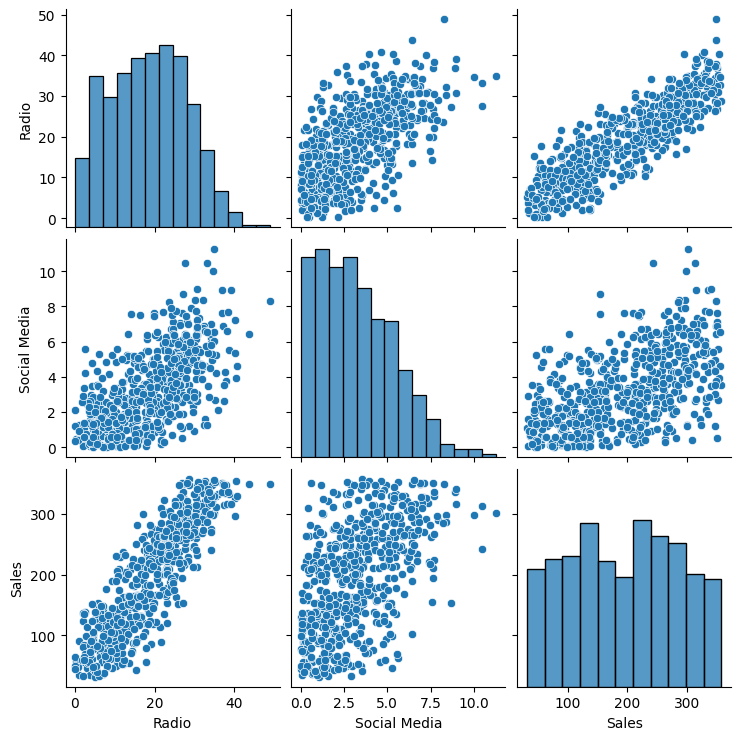

In [49]:
# Create plot of pairwise relationships.

sns.pairplot(data)


**Question:** Is the assumption of linearity met?


The assumption of linearity is met, given that everytime more money was spent on radio marketing (x variable), it generated more sales (y variable )

## **Step 3: Model building & Fitting the data**

Select only the columns that are needed for the model.

### we are gonna create a subset df with radio and sales columns (use double brackets) [[]]
### Im gonna name the subset df ols_data

In [51]:
# Select relevant columns.
# Save resulting DataFrame in a separate variable to prepare for regression.

ols_data = data[["Radio","Sales"]]


Now, display the first 10 rows of the new DataFrame to better understand the data.

In [52]:
# Display first 10 rows of the new DataFrame.

ols_data.head(10)


,Radio,Sales
0,1.218354,90.054222
1,14.949791,222.741668
2,10.377258,102.774790
3,26.469274,328.239378
4,36.876302,351.807328
5,25.561910,261.966812
6,37.263819,349.861575
7,13.187256,140.415286
8,29.520170,264.592233
9,3.773287,55.674214


write the linear regression formula

Model the relationship between the two variables of interest. (Radio And Sales )

In [57]:
# Write the linear regression formula.
# Save it in a variable.

ols_formula = "Sales ~ Radio"


Now, implement the ordinary least squares (OLS) approach for linear regression.

In [59]:

# Import ols function
from statsmodels.formula.api import ols


In [62]:
# Implement OLS
OLS = ols(formula = ols_formula, data = ols_data)


# Fit the model to the data.
# Save the fitted model in a variable.

model  = OLS.fit()


## **Step 4: Results and evaluation**


In [64]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     1768.
Date:                Wed, 30 Sep 2026   Prob (F-statistic):          2.07e-176
Time:                        19:05:12   Log-Likelihood:                -2966.7
No. Observations:                 569   AIC:                             5937.
Df Residuals:                     567   BIC:                             5946.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.5326      4.067     10.211      0.000      33.544      49.521
Radio          8.1733      0.194     42.048      0.000       7.791       8.555
==============================================================================
Omnibus:                        2.267   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.322   Jarque-Bera (JB):                2.221
Skew:                          -0.102   Prob(JB):                        0.329
Kurtosis:                       2.772   Cond. No.                         45.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Next, analyze the bottom table from the results summary. Based on the table, identify the coefficients that the model determined would generate the line of best fit. The coefficients are the y-intercept and the slope.

**Question:** What is the y-intercept?


is 41.53 millions $$ in sales

**Question:** What is the slope?

8.17 millions

**What linear equation would you write to express the relationship between sales and radio promotion budget? Use the form of y = slope * x + y-intercept?**

y = 8.17 * x + 41.53


**Question:** What does the slope mean in this context?

For every 1 million increase in radio marketing spend, Sales will increase by 8.17 millions




### finish checking the model assumptions.

This will help confirm your findings.
First, plot the OLS data with the best fit regression line.
 sns.regplot function from seaborn


 using this subset df you created earlier data = ols_data  with only 2 columns Radio and Sales

<Axes: xlabel='Radio', ylabel='Sales'>

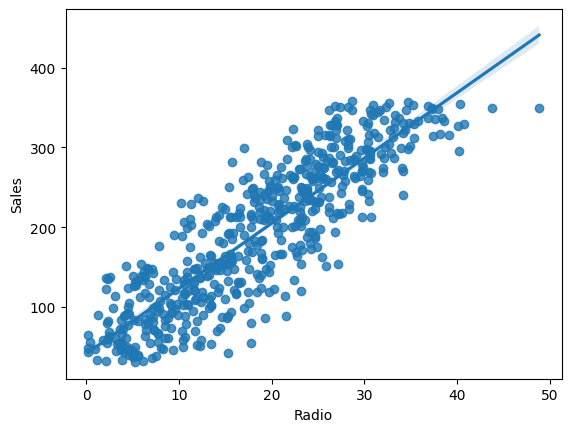

In [66]:
# Plot the OLS data with the best fit regression line.

sns.regplot(x = "Radio", y = "Sales", data = ols_data)


 What do you observe from the preceding regression plot?

 I observe that the regression is linear, as x changes so does y




Now, check the normality assumption. Get the residuals from the model.

the normal distribution is 68, 95, 98

In [67]:
# Get the residuals from the model.
# calculate residuals

residuals = model.resid



Now, visualize the distribution of the residuals.

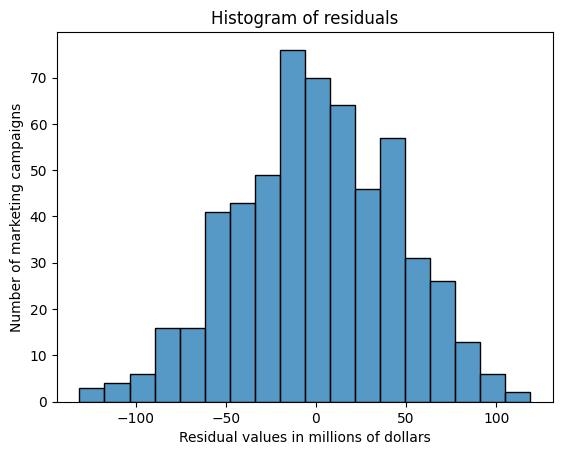

In [79]:
# Visualize the distribution of the residuals.
# we will use a histoplot

import matplotlib.pyplot as plt

fig = sns.histplot(residuals)
fig.set_xlabel("Residual values in millions of dollars")
fig.set_ylabel("Number of marketing campaigns")

fig.set_title("Histogram of residuals")
plt.show()


**Question:** Based on the visualization, what do you observe about the distribution of the residuals?


Your formula gives you an educated guess: If you spend $10M  on radio,

your formula predicts about $123 M
 in sales ($8.17 x 10 + 41.53$).


The $-\$50\text{M}$ to $+\$50\text{M}$ is the normal margin of error: In real life,

that campaign won't hit $123M on the dot.


 It will usually land somewhere between $73M and $173M.





Next, create a Q-Q plot to confirm the assumption of normality.

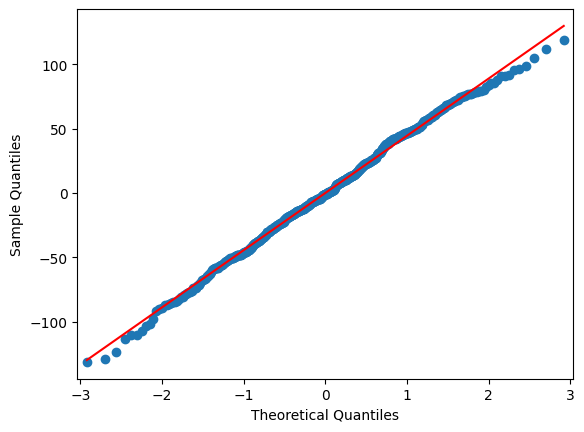

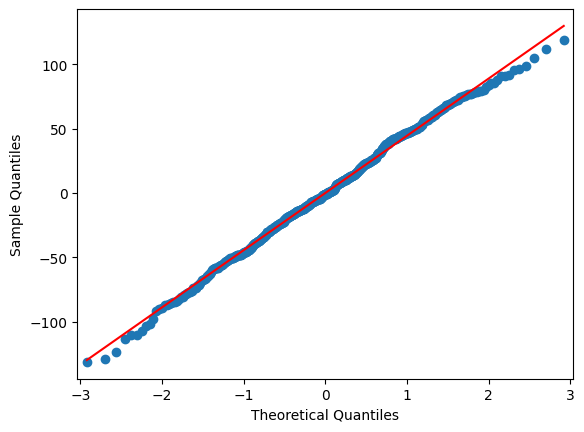

In [84]:
# Create a Q-Q plot.
import matplotlib.pyplot as plt
import statsmodels.api as sm

sm.qqplot(model.resid,line = "s")




**Question:** Is the assumption of normality met?

yes, the assumption of normal distribution is met, meaning
95% of the values fall within 2 std

The points tightly track the straight red diagonal line throughout the entire middle range (from theoretical quantiles -2 to +2).

The tails: There is only very slight deviation at the extreme ends (past -2.5 and +2.5), which is typical and acceptable for real-world data.

Now, check the assumptions of independent observation and homoscedasticity. Start by getting the fitted values from the model.

In [88]:
# Get fitted values.

X = ols_data["Radio"]


# # we are gonna create a variable to store these predictions called Fitted_values

fitted_values = model.predict(X)



Next, create a scatterplot of the residuals against the fitted values.

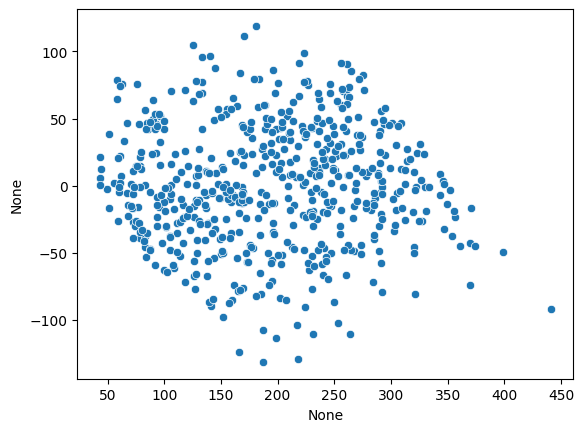

In [89]:
# Create a scatterplot of residuals against fitted values.




fig = sns.scatterplot(x=fitted_values, y=residuals)




**Question:** Are the assumptions of independent observation and homoscedasticity met?


independent observations is met, meaning the result of one independent campaign are unlikely to affect the next campaign

Homoscedasticity : Yes, met. Looking at the scatterplot of residuals against fitted values, the points form a random cloud/band around zero. The vertical spread (dispersion) of the points remains fairly uniform and consistent across all fitted values, with no obvious funnel, cone, or fan shape.




If any of the four core assumptions (Linearity, Normality, Independent Observations, or Homoscedasticity) fail, standard Ordinary Least Squares (OLS) linear regression breaks down:

If Linearity fails: The relationship isn't a straight line. Fitting a line forces a flat rate of return that misrepresents reality, meaning you would need polynomial terms, logarithmic transformations, or non-linear models.

If Independent Observations fail: Standard errors are underestimated, meaning p-values look artificially significant and confidence intervals are too narrow.

If Normality fails: The hypothesis tests (t-tests, F-test) and confidence intervals become unreliable, especially in smaller datasets.

If Homoscedasticity fails (Heteroscedasticity): The standard errors are biased, meaning you cannot trust the p-values or confidence intervals to tell you if radio spend is genuinely statistically significant.

When these assumptions fail, you either have to transform the data (e.g., log transforms), use robust standard errors, or switch to alternative modeling approaches (such as generalized linear models, tree-based models, or time-series models).

## **Considerations**

**What are some key takeaways that you learned during this lab?**

**How would you present your findings from this lab to others?**

**What summary would you provide to stakeholders?**

**References**

[Pandas.DataFrame.Any — Pandas 1.4.3 Documentation.](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.any.html)

[Pandas.DataFrame.Isna — Pandas 1.4.3 Documentation.](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html)

[Pandas.Series.Sum — Pandas 1.4.3 Documentation.](https://pandas.pydata.org/docs/reference/api/pandas.Series.sum.html)

[Saragih, H.S. *Dummy Marketing and Sales Data*.](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data)

**Congratulations!** You've completed this lab.